In [1]:
# Basic imports and setup
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import corner

# Import the new data loader and plotting functions
from analyze_modules import ChelioRun

# get viridis colormap
cmap = plt.get_cmap('viridis')
cmap.set_bad(color='black')
plt.rcParams['figure.dpi'] = 200

In [2]:
def set_white(ax):
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    ax.tick_params(axis='x', colors='white', which='both')  # Set color for both major and minor ticks
    ax.tick_params(axis='y', colors='white', which='both')  # Set color for both major and minor ticks

def increase_size(ax, linewidth=3, fontsize=14, legendcols=1, legendloc='best'):
    for l in ax.lines:
        l.set_linewidth(linewidth)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(linewidth)
    ax.set_title(ax.get_title(), fontsize=fontsize)
    ax.xaxis.set_tick_params(width=linewidth)
    ax.yaxis.set_tick_params(width=linewidth)
    ax.xaxis.label.set_size(fontsize)
    ax.yaxis.label.set_size(fontsize)
    ax.xaxis.set_tick_params(labelsize=fontsize)
    ax.yaxis.set_tick_params(labelsize=fontsize)
    if legendloc != 'no':
        ax.legend(fontsize=fontsize, ncols=legendcols, loc=legendloc)

In [3]:
# Define parameters for the matrix
folder = '../output/Atmodeller/'

Tints = np.array([50, 100, 150, 200])
Tmelts = np.array([1000, 2000])
Hoceans = np.array([0.1, 1.0, 10.0])
CtoHs = np.array([0.1, 1.0, 10.0])
NtoCs = np.array([0.01, 0.1, 1.0])
fO2s = np.array([-3, 0, 3])

var_params = [Tmelts, Hoceans, CtoHs, NtoCs, fO2s]
var_param_names = ['Tmelt', 'Hocean', 'CtoH', 'NtoC', 'fO2']
param_log = [False, True, True, True, False]

# Define the parameter grid
param_grid = np.meshgrid(*var_params)
print(param_grid[0].shape)

# Flatten the parameter grid
param_grid = np.array([p.flatten() for p in param_grid])
print(param_grid.shape)

(3, 2, 3, 3, 3)
(5, 162)


In [57]:
Tint = 200
runs = []

for i in range(param_grid.shape[1]):
    ntoc_str = f"{param_grid[3, i]:.1f}" if param_grid[3, i] >= 1.0 else f"{param_grid[3, i]:.1g}"
    run_name = f"Earth_Tint={Tint}_Tmelt={param_grid[0, i]:.0f}_Hocean={param_grid[1, i]:.1f}_CtoH={param_grid[2, i]:.1f}_NtoC={ntoc_str}_fO2={param_grid[4, i]:.0f}"
    #print(run_name)
    run = ChelioRun(folder, run_name)
    run.read_data()
    run.convert_to_vmr()
    runs.append(run)

converged_mask = np.array([run.final_convergence_status for run in runs])
converged = converged_mask.sum()
print(f"Number of converged runs: {converged}, {converged/len(runs)*100:.2f}%")

Number of converged runs: 144, 88.89%


In [58]:
# get outgassed data

vmrs = {}
Psurfs = np.zeros(len(runs))
PTs = []

for i, run in enumerate(runs):
    run_name = run.run_name + '_outgassed'
    p_file = folder + run_name + '/P_BOA.dat'
    vmrs_file = folder + run_name + '/species.dat'
    try:
        with open(p_file, 'r') as f:
            Psurfs[i] = float(f.readline())*1e-6
        with open(vmrs_file, 'r') as f:
            for j, line in enumerate(f):
                if j != 0 and line != '\n':
                    line = line.split()
                    if line[0] == 'CIA_N2N2':
                        mol, vmr = 'N2', float(line[-1].split('&')[0])
                    elif line[0][:3] == 'CIA':
                        continue
                    else:
                        mol, vmr = line[0], float(line[-1])
                    
                    if mol not in vmrs:
                        vmrs[mol] = []
                    vmrs[mol].append(vmr)
        try:
            pt_file = folder + run_name + f'/{run_name}_tp_cut.dat'
            pt = np.loadtxt(pt_file, skiprows=2, usecols=(2,1))
            pt[:,0] *= 1e-6 # dyn/cm^2 to bar
            PTs.append(pt)
        except:
            PTs.append(np.array([[np.nan, np.nan]]))
    except:
        Psurfs[i] = np.nan
        PTs.append(np.array([[np.nan, np.nan]]))

for mol in vmrs.keys():
    vmr = np.array(vmrs[mol])
    vmrs[mol] = np.empty_like(Psurfs)
    vmrs[mol][:] = np.nan
    mask = np.logical_not(np.isnan(Psurfs))
    vmrs[mol][mask] = vmr

converged 144
low P 18
GGchem fails 126


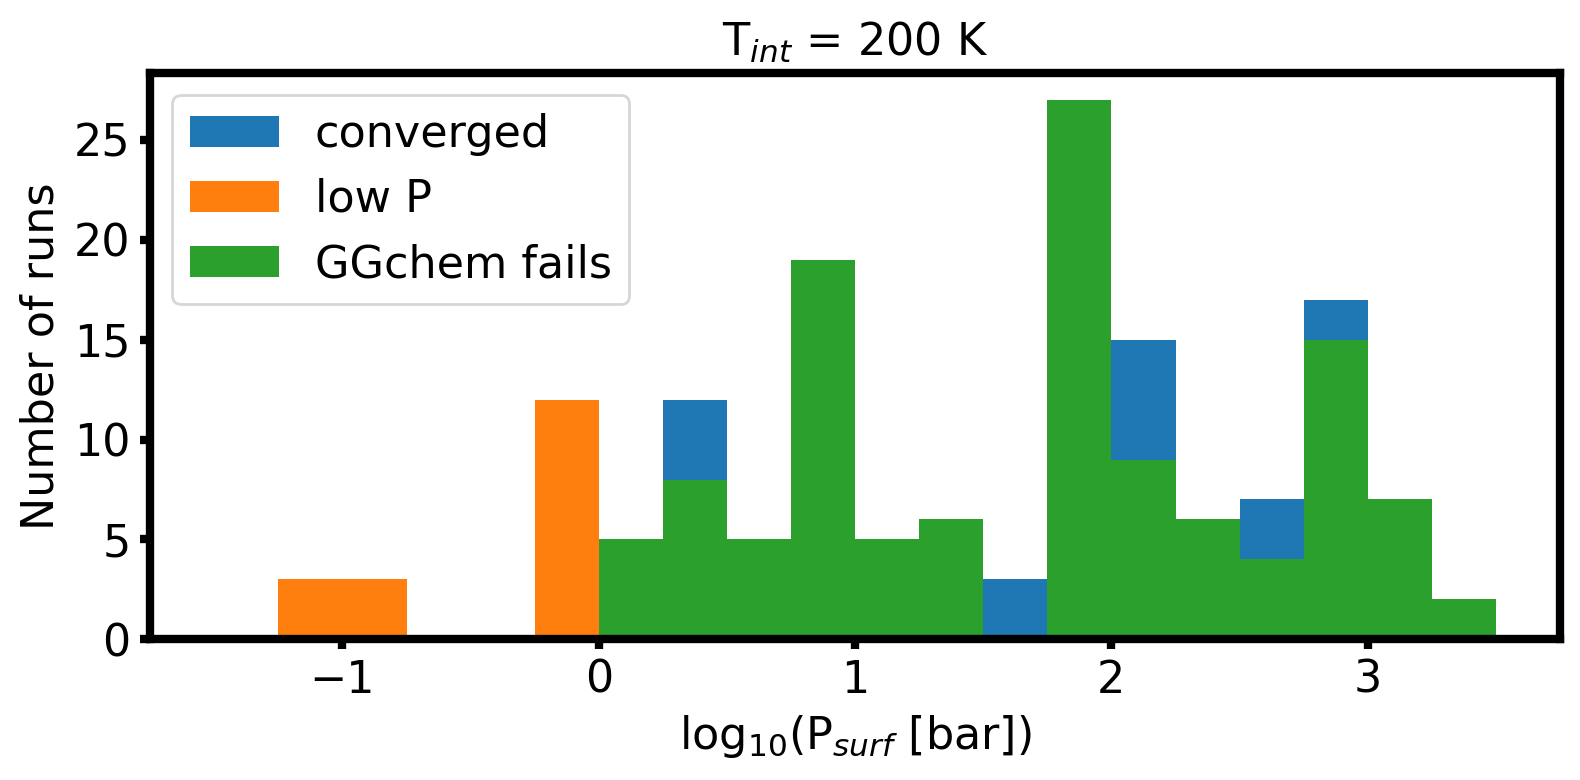

In [59]:
mask_lowP = Psurfs < 1e0
mask_noConv = np.logical_and(np.logical_not(converged_mask), np.logical_not(mask_lowP))
mask_noConv = np.logical_and(mask_noConv, np.logical_not(np.isnan(Psurfs)))
mask_Tconst = np.array([np.all(np.abs(run.temperatures_K[0,:] - 500) < 1e-1) for run in runs])

if np.sum(mask_noConv) > 0:
    labels = ['converged', 'low P', 'GGchem fails', 'not converged']
    masks = [converged_mask, mask_lowP, mask_Tconst, mask_noConv]
else:
    labels = ['converged', 'low P', 'GGchem fails']
    masks = [converged_mask, mask_lowP, mask_Tconst]

plt.figure(figsize=(8,4))

for i,mask in enumerate(masks):
    print(labels[i], np.sum(mask))
    plt.hist(np.log10(Psurfs[mask]), bins=20, range=(-1.5, 3.5), label=labels[i])

plt.xlabel(r'log$_{10}$(P$_{surf}$ [bar])')
plt.ylabel('Number of runs')
plt.legend()
increase_size(plt.gca(), linewidth=3, fontsize=16, legendloc='best')
plt.title(r'T$_{int}$ = ' + f'{Tint} K', fontsize=16)
plt.tight_layout()

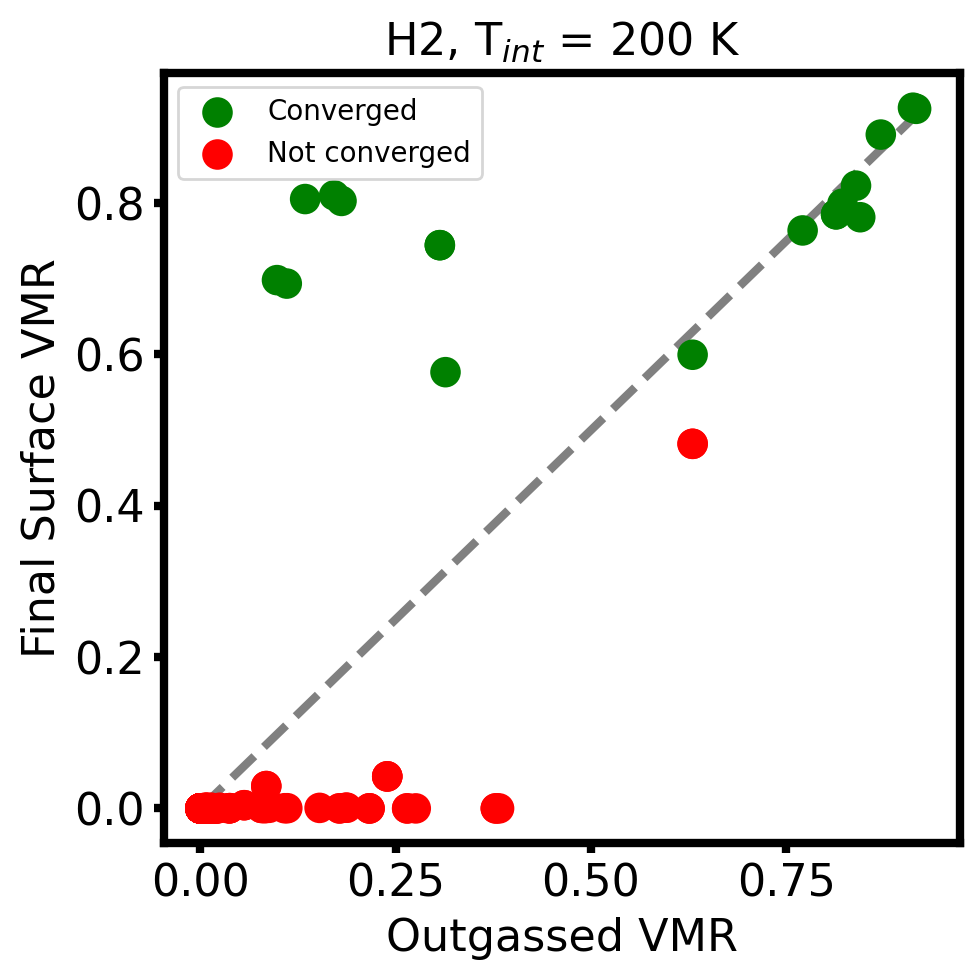

In [60]:
# compare abundances

layer = 0 # (surface layer = 0)
#colors = np.array([run.iterations_read[-1] for run in runs])
#colors = plt.cm.plasma(colors/(np.nanmax(colors)+1))
colors = ['green' if run.iterations_read[-1] > 0 else 'red' for run in runs]

plot_all = False
if plot_all:
    n_mols = len(vmrs.keys())
    n_rows = 2 #np.ceil(np.sqrt(n_mols)).astype('int')
    n_cols = np.ceil(n_mols/n_rows).astype('int')
    
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(10,5), dpi=200)
    
    for i, mol in enumerate(vmrs.keys()):
        ax = axs[i//n_cols, i%n_cols]
        ggchem_vmr = np.zeros_like(Psurfs)
        for j, run in enumerate(runs):
            if run.final_convergence_status:
                i_mol = run.mol_names.index(mol)
                ggchem_vmr[j] = run.mols_vmr[0, layer, i_mol]

        ax.scatter(vmrs[mol], ggchem_vmr, c=colors, s=10)
        max_vmr = np.max([np.nanmax(vmrs[mol]), np.nanmax(ggchem_vmr)])
        ax.plot(np.linspace(0,max_vmr,100), np.linspace(0,max_vmr,100), "--", color='grey', zorder=-1)
        #ax.plot(np.linspace(0,1,100), np.linspace(0,1,100), "--", color='black')
        #ax.set_xlim(0,1)
        #ax.set_ylim(0,1)
        ax.set_title(mol)

    fig.supxlabel('Outgassed VMR')
    fig.supylabel('Final Surface VMR')

else:
    mol = 'H2'
    fig, ax = plt.subplots(figsize=(5,5), dpi=200)
    for j, run in enumerate(runs):
            if run.final_convergence_status:
                i_mol = run.mol_names.index(mol)
                ggchem_vmr[j] = run.mols_vmr[0, layer, i_mol]

    ax.scatter(vmrs[mol], ggchem_vmr, c=colors, s=100)
    max_vmr = np.max([np.nanmax(vmrs[mol]), np.nanmax(ggchem_vmr)])
    ax.plot(np.linspace(0,max_vmr,100), np.linspace(0,max_vmr,100), "--", color='grey', zorder=-1)
    ax.set_title(f'{mol}, ' + r'T$_{int}$ = ' + f'{Tint} K')
    ax.set_xlabel('Outgassed VMR')
    ax.set_ylabel('Final Surface VMR')
    
    handles = [plt.scatter([], [], c='green', s=100, label='Converged'), plt.scatter([], [], c='red', s=100, label='Not converged')]
    ax.legend(handles=handles, loc='best')

#set_white(ax)
increase_size(ax, linewidth=3, fontsize=16, legendloc='no')
fig.tight_layout()

#fig.savefig(f'images/Poster_Venice/ggchem_vmr_comparison_{mol}.svg', format='svg', transparent=True)

converged 144
low P 18
GGchem fails 126


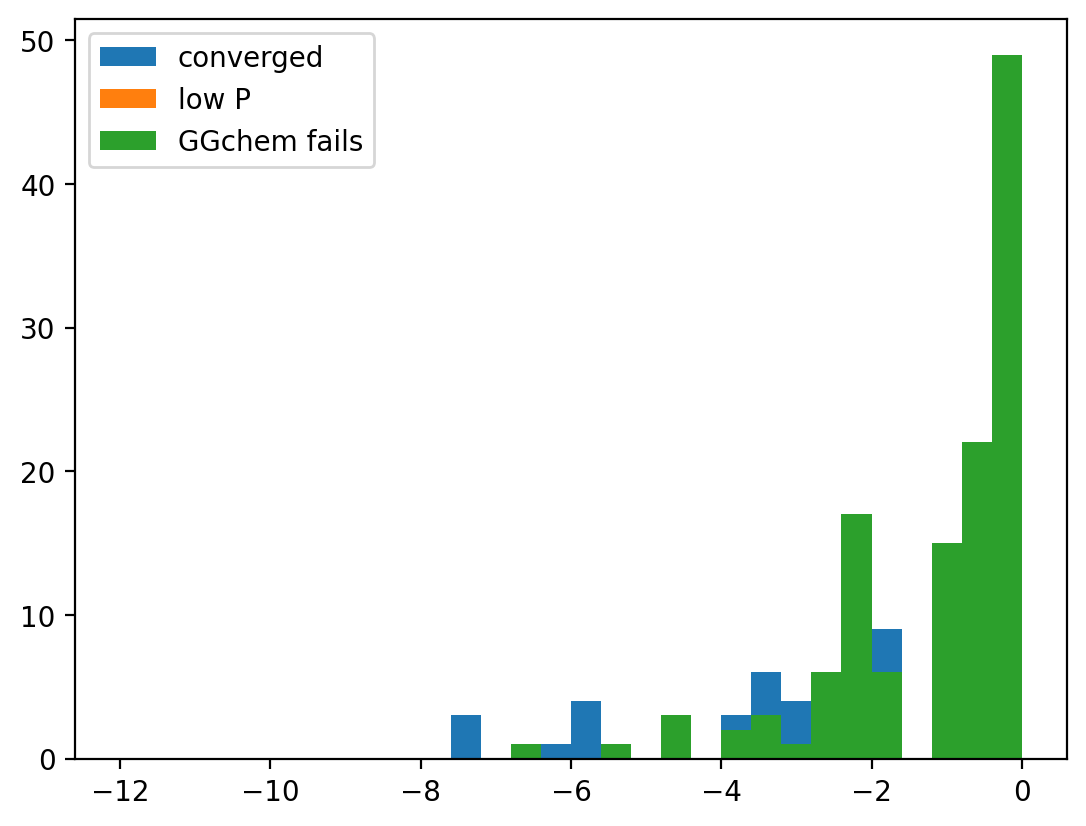

In [61]:
for i,mask in enumerate(masks):
    print(labels[i], np.sum(mask))
    plt.hist(np.log10(vmrs['CO2'][mask]), bins=30, range=(-12, 0), label=labels[i])

plt.legend()

Earth_Tint=200_Tmelt=1000_Hocean=1.0_CtoH=0.1_NtoC=0.01_fO2=-3: 2.3 bar, 476 K
Earth_Tint=200_Tmelt=1000_Hocean=1.0_CtoH=0.1_NtoC=0.1_fO2=-3: 2.4 bar, 568 K
Earth_Tint=200_Tmelt=1000_Hocean=1.0_CtoH=0.1_NtoC=1.0_fO2=-3: 3.1 bar, 660 K
Earth_Tint=200_Tmelt=1000_Hocean=1.0_CtoH=1.0_NtoC=0.01_fO2=-3: 2.4 bar, 568 K
Earth_Tint=200_Tmelt=1000_Hocean=10.0_CtoH=0.1_NtoC=0.01_fO2=-3: 113.2 bar, 1487 K
Earth_Tint=200_Tmelt=1000_Hocean=10.0_CtoH=0.1_NtoC=0.01_fO2=0: 53.9 bar, 1196 K
Earth_Tint=200_Tmelt=1000_Hocean=10.0_CtoH=0.1_NtoC=0.1_fO2=-3: 114.6 bar, 1634 K
Earth_Tint=200_Tmelt=1000_Hocean=10.0_CtoH=0.1_NtoC=0.1_fO2=0: 55.3 bar, 1412 K
Earth_Tint=200_Tmelt=1000_Hocean=10.0_CtoH=0.1_NtoC=1.0_fO2=-3: 129.6 bar, 1681 K
Earth_Tint=200_Tmelt=1000_Hocean=10.0_CtoH=1.0_NtoC=0.01_fO2=-3: 409.6 bar, 1775 K
Earth_Tint=200_Tmelt=1000_Hocean=10.0_CtoH=1.0_NtoC=0.01_fO2=0: 55.3 bar, 1412 K
Earth_Tint=200_Tmelt=1000_Hocean=10.0_CtoH=1.0_NtoC=0.1_fO2=-3: 432.7 bar, 1838 K
Earth_Tint=200_Tmelt=1000_Hocean

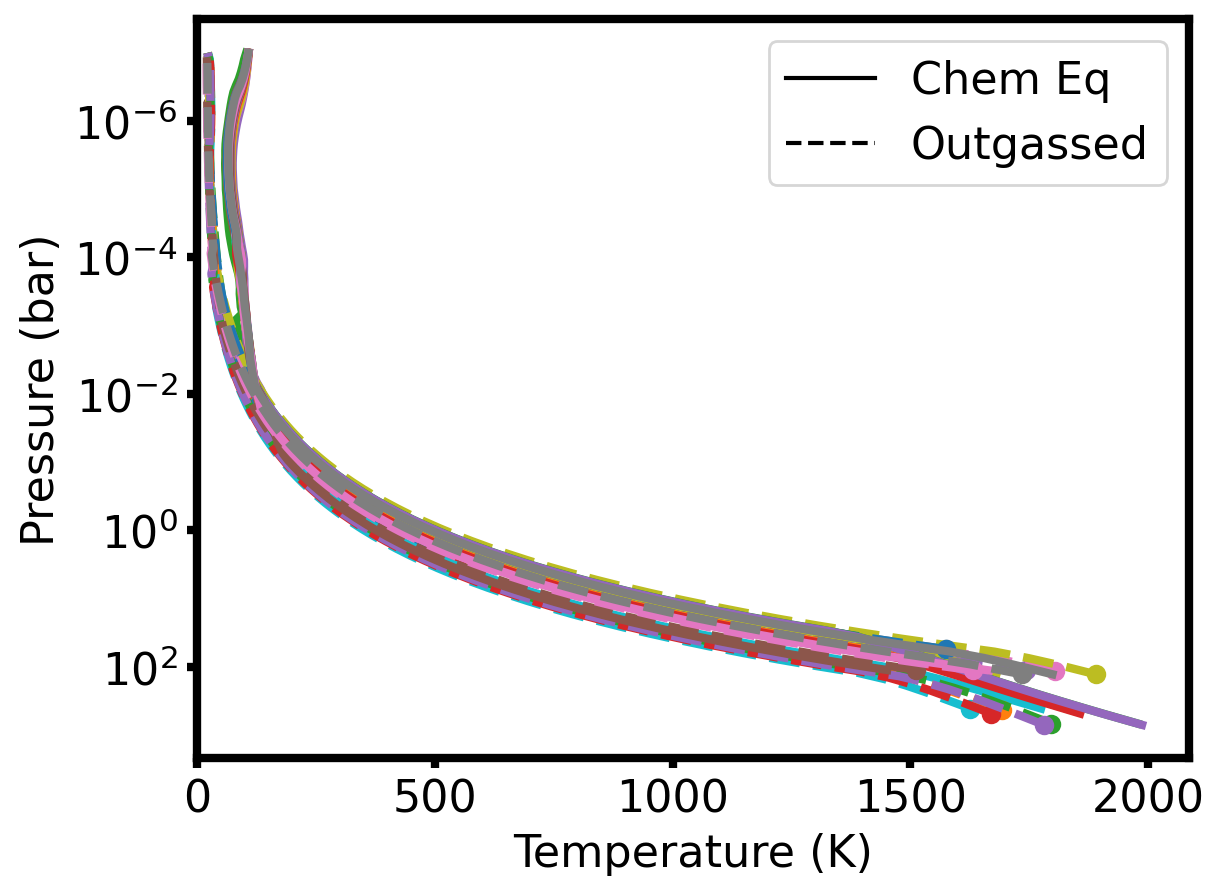

In [63]:
# plot temperature profiles
for i, run in enumerate(runs):
    if run.final_convergence_status:
        if np.all(np.abs(run.temperatures_K[0,:] - 500) > 1e-1):
            print(f'{run.run_name}: {run.pressures_bar[0,0]:.1f} bar, {run.temperatures_K[0,0]:.0f} K')
            line = plt.plot(run.temperatures_K[0,:], run.pressures_bar[0,:], label=run.run_name)
            plt.plot(PTs[i][:,1], PTs[i][:,0], color=line[0].get_color(), linestyle='--')
            plt.plot(PTs[i][0,1], PTs[i][0,0], color=line[0].get_color(), marker='o')

plt.yscale('log')
plt.gca().invert_yaxis()
plt.xlim(0, None)
#plt.ylim(5e2, 1e0)
plt.xlabel('Temperature (K)')
plt.ylabel('Pressure (bar)')
#plt.legend(bbox_to_anchor=(1.1, 0.3))

legend_labels = ['Chem Eq', 'Outgassed']
linestyles = ['-', '--']
handles, labels = [], []
for linestyle, label in zip(linestyles, legend_labels):
    handles.append(plt.Line2D([0], [0], color='black', linestyle=linestyle))
    labels.append(label)
plt.legend(handles=handles, labels=labels, loc='best', fontsize=16)

increase_size(plt.gca(), linewidth=3, fontsize=16, legendloc='no')

plt.show()

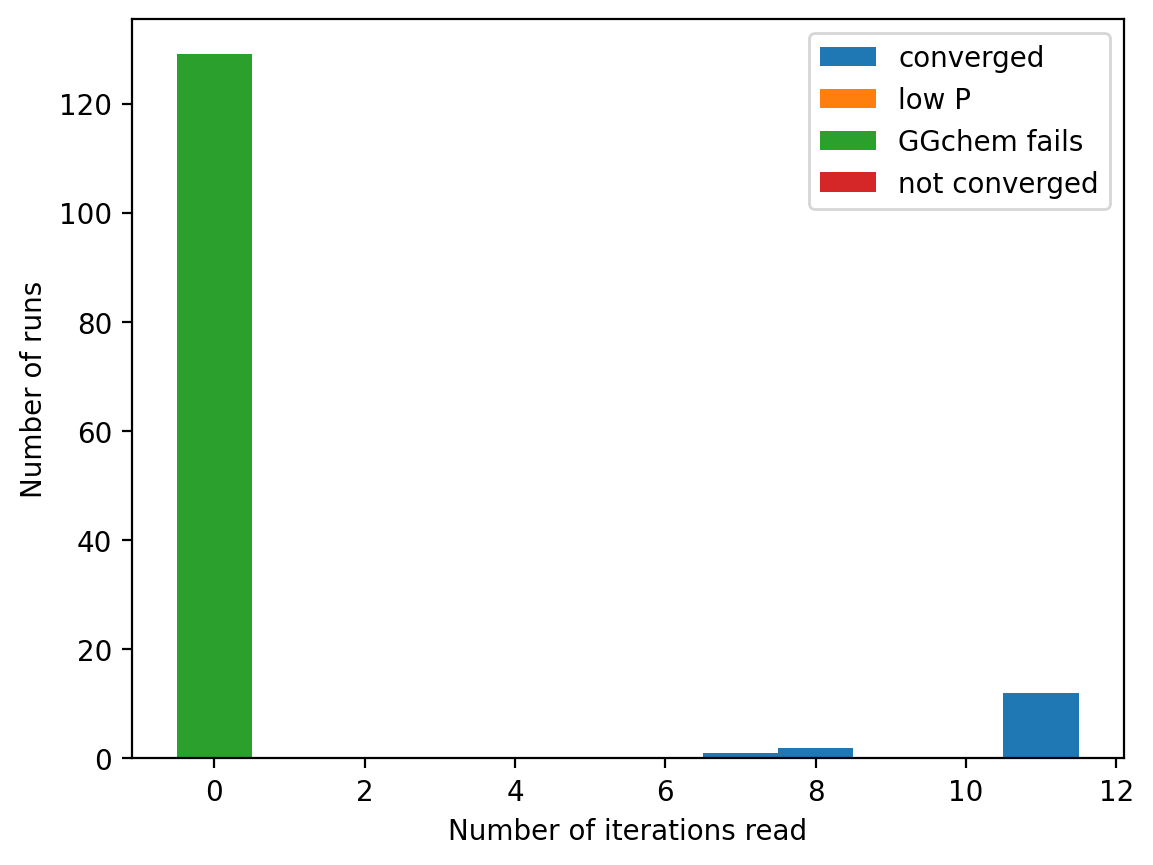

In [23]:
param = 'iterations_read'

param_array = np.array([getattr(run, param) for run in runs])

for i, mask in enumerate(masks):
    plt.hist(param_array[mask], bins=12, range=(-0.5, 11.5), label=labels[i])
plt.xlabel('Number of iterations read')
plt.ylabel('Number of runs')
plt.legend()
plt.show()

162 162
[nan, nan, nan, nan, nan, nan, nan, 77.2335, 77.3122, nan, 80.6134, 92.7854, nan, 81.7813, 93.1187, 84.6976, 89.052, 95.7592, nan, 81.7813, 117.812, 84.6976, 89.052, 118.212, 118.625, 107.221, 122.535, nan, nan, nan, nan, nan, nan, nan, nan, 77.5349, 87.4141, 92.8811, 92.9608, 87.6127, 93.2444, 93.2899, 92.0178, 96.351, 96.0784, 105.055, 117.454, 118.309, 106.037, 117.848, 118.687, 115.876, 121.656, 122.883, 187.525, 124.078, nan, 182.925, 128.785, 133.195, 202.14, 149.185, 136.778, 182.925, 128.785, 152.96, 202.14, 149.185, 158.239, 268.59, 201.55, 173.185, 202.14, 149.185, 267.452, 268.59, 201.55, 274.432, 383.446, 284.742, 295.954, 137.506, 130.952, 131.625, 142.508, 132.455, 131.886, 159.382, 137.159, nan, 164.058, 144.89, 150.449, 193.939, 150.567, 150.76, 229.363, 176.604, 153.169, 227.398, 232.085, 268.035, 255.299, 242.894, 269.51, 303.234, 271.091, 277.881, 577.84, 452.746, 333.152, 582.409, 460.353, 364.048, 598.26, 483.143, 404.652, 624.871, 460.353, 505.738, 633.423

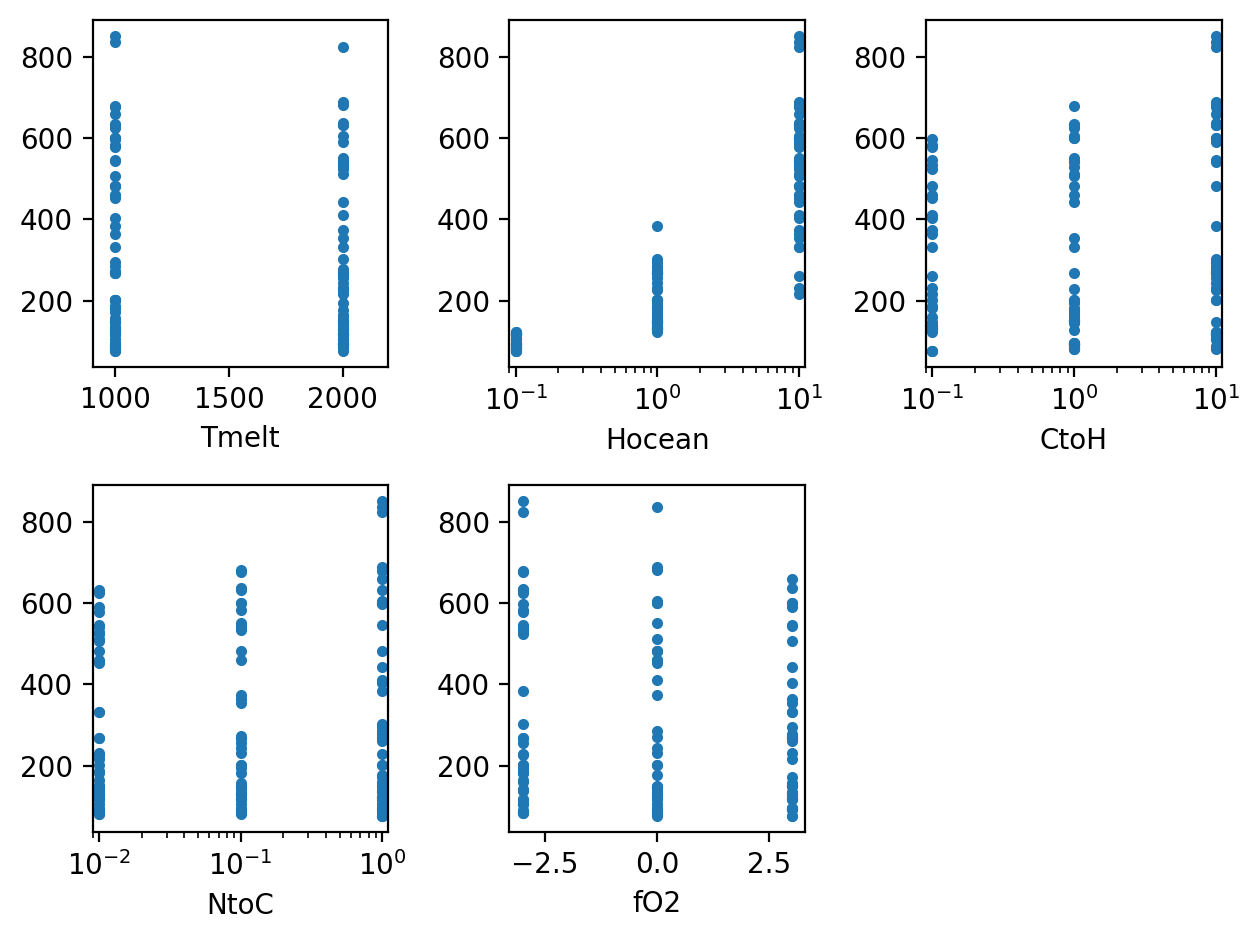

In [24]:
fig, ax = plt.subplots(2,3)
ax = ax.flatten()

print(len(runs), len(PTs))
#y_data = [run.temperatures_K[0,0] if abs(run.temperatures_K[0,0] - 500) > 1e-1 else np.nan for run in runs]
y_data = [PTs[j][0,1] for j in range(len(PTs))]
print(y_data)

for i,p in enumerate(param_grid):
    ax[i].plot(p, y_data, '.')
    if param_log[i]:
        ax[i].set_xscale('log')
    ax[i].set_xlim(p.min()*(1-0.1*np.sign(p.min())), p.max()*(1+0.1*np.sign(p.max())))
    #ax[i].set_yscale('log')
    ax[i].set_xlabel(var_param_names[i])
    #ax[i].set_ylabel('Pressure (bar)')

# delete empty subplots
ax[-1].remove()

fig.tight_layout()